In [1]:
import numpy as np
from scipy.stats import poisson,multivariate_normal
from scipy.optimize import minimize
import itertools
import matplotlib.pyplot as plt

In [3]:
# Arguments:
# n: l dimensional array of observed bin values
# s: l dimensional array of expected signal for a given model
# b: l dimensional array of expected background for a given (bkg) model
# b0: l dimensional array of central values for the background
# C: covariance matrix for the background
# pval: p-value for "exclusion"

# Determine the background that maxmizes the likelihood at fixed signal (profile likelihood)
def prof_max(n,s,b0,C):
    l = len(n)
    return minimize(lambda b : -P(n,s,b,b0,C),b0,bounds=[(0.,5*b0[i]) for i in range(l)]).x
# Determine the signal and background that maximize the likelihood (maximum likelihood)
def best_max(n,b0,C):
    l = len(n)
    return minimize(lambda combo : -P(n,combo[:l],combo[l:],b0,C),np.concatenate((np.maximum(np.zeros((l)),n-b0),b0)),bounds=[(0.,np.inf) for i in range(2*l)]).x
# The likelihood function
def P(n,s,b,b0,C):
    return np.prod(poisson.pmf(n,s+b)) * multivariate_normal.pdf(b,b0,C)
# Profile likelihood ratio
def R(n,s,b0,C):
    l = len(n)
    bhh = prof_max(n,s,b0,C)
    sbh = best_max(n,b0,C)
    sh = sbh[:l]
    bh = sbh[l:]
    return P(n,s,bhh,b0,C) / P(n,sh,bh,b0,C)
# Loop to determine acceptable n tuples
def accepted_n(s,b0,C,pval = 0.9):
    l = len(s)
    Ptot = 0.
    n_list = []
    n_each = []
    # First create list of n to scan over
    # Truncate when P becomes very small
    for i in range(l):
        n_this = list(range(int(np.ceil(5 * (b0[i] + s[i])))))
        n_each.append(n_this)
    R_ord = []
    norm = 0.0
    # Evaluate the R for each n tuple and also determine normalization for profile likelihood
    for n_tuple in itertools.product(*n_each):
        n_this = np.array(n_tuple)
        R_this = R(n_this,s,b0,C)
        R_ord.append([n_this,R_this])
        norm += P(n_this,s,prof_max(n_this,s,b0,C),b0,C)
    # Sort the R from largest R to smallest
    R_ord.sort(reverse=  True,key = lambda p : p[1])
    i = 0
    # Keep adding n until we exceed the desired p-value according to Feldman-Cousins
    while True:
        n_this = np.array(R_ord[i][0])
        R_this = R_ord[i][1]
        bhh = prof_max(n_this,s,b0,C)
        Ptot = Ptot + P(n_this,s,bhh,b0,C) / norm
        if Ptot > pval:
            break
        n_list.append(n_this)
        i = i + 1
    return np.array(n_list)

In [4]:
acc_test = accepted_n(np.array([4.,6.]),
                      np.array([3.0,2.0]),
                      np.array([[1.5*1.5,0],[0,1.0*1.0]]))

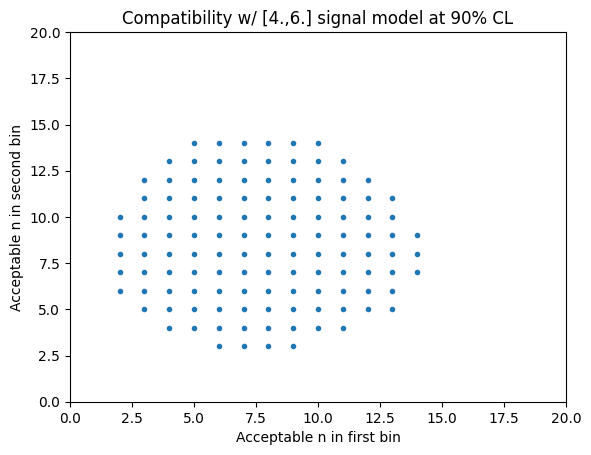

In [5]:
plt.plot(acc_test[:,0],acc_test[:,1],ls='None',marker='.')
plt.xlim(0,20)
plt.ylim(0,20)
plt.title('Compatibility w/ [4.,6.] signal model at 90% CL')
plt.xlabel('Acceptable n in first bin')
plt.ylabel('Acceptable n in second bin')
plt.show()